In [ ]:
import gdown
file_id = '1gusYVaiM0l_YjR1IzRtLwpj9fcAbLE1z'
download_url = f'https://drive.google.com/uc?id={file_id}'
output = 'credit_card_eligibility.csv'
gdown.download(download_url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1gusYVaiM0l_YjR1IzRtLwpj9fcAbLE1z
To: /content/credit_card_eligibility.csv
100%|██████████| 1.33M/1.33M [00:00<00:00, 15.4MB/s]


'credit_card_eligibility.csv'

In [ ]:
import numpy as np
import pandas as pd

class Preprocessor:
    def __init__(self):
        self.data = None

    def run(self, filepath):
        self.data = pd.read_csv(filepath)
        self.cleaning()
        y_preprocessed = self.setTarget()
        x_preprocessed = self.normalize()
        return x_preprocessed, y_preprocessed

    def cleaning(self):
        self.data = (self.data
            .drop(columns=['ID'])
            .dropna()
            .drop_duplicates()
        )
        return self

    def normalize(self):
        x_numeric = self.data.select_dtypes(
            include=np.number).values
        x_preprocessed = (
            x_numeric - x_numeric.mean(axis=0)
            ) / x_numeric.std(axis=0)
        return x_preprocessed

    def setTarget(self):
        y_preprocessed = self.data['Target'].values.reshape(-1, 1)
        return y_preprocessed

In [ ]:
class Partitioner:
    def __init__(self, splitter):
        self.splitter = splitter

    def run(self, x, y, test_size):
        x_train, x_test, y_train, y_test = self.splitter(
            x, y, test_size=test_size, stratify=y)
        return x_train, y_train, x_test, y_test

In [ ]:
class Resampler:
    def __init__(self, resampler):
        self.resampler = resampler

    def run(self, x,y):
        x_resampled, y_resampled = self.resampler.fit_resample(x, y)
        return x_resampled, y_resampled

In [ ]:
class Processor:
    def __init__(self, path, preprocessor, partitioner, resampler):
        self.path = path
        self.preprocessor = preprocessor
        self.partitioner = partitioner
        self.resampler = resampler
        self.test_size = None

    def run(self, test_size):
        x_preprocessed, y_preprocessed = self.preprocessor.run(self.path)
        x_train, y_train, x_test, y_test = self.partitioner.run(x_preprocessed, y_preprocessed, test_size)
        x_train_resampled, y_train_resampled = self.resampler.run(x_train, y_train)
        y_train_resampled = y_train_resampled.reshape(-1,1)
        return x_train_resampled, y_train_resampled, x_test, y_test

In [ ]:
import numpy as np
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)
def binaryCrossEntropyLoss(y_true, y_pred):
    eps = 1e-8  # avoid log(0)
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def measurePerformanceMetrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    return accuracy, precision, recall, f1, roc_auc


In [ ]:
import numpy as np

class BackPropagationNeuralNetwork:
    def __init__(self):
        self.activation = None
        self.activation_deriv = None
        self.loss = None
        self.learning_rate = None
        self.epochs = None
        self.batch_size = None
        self.weights = []
        self.biases = []
        self.zs = []
        self.activations = []
        self.losses = []
        self.accuracy = 0.0

    def fit(self, X, y):
        loss = 0
        n_samples = X.shape[0]
        for epoch in range(self.epochs):
            # shuffle
            indices = np.random.permutation(n_samples)
            X_sh, y_sh = X[indices], y[indices]
            for start in range(0, n_samples, self.batch_size):
                X_batch = X_sh[start:start + self.batch_size]
                y_batch = y_sh[start:start + self.batch_size]
                y_pred = self.feedForward(X_batch)
                loss = self.loss(y_batch, y_pred)
                self.losses.append(loss)
                self.backPropagate(y_batch, y_pred)
            if (epoch + 1) % 10 == 0 or epoch == self.epochs - 1:
                print(f"Epoch {epoch+1}/{self.epochs} - Loss: {loss:.4f}")
        return self

    def feedForward(self, X):
        """Perform forward pass through all layers"""
        self.zs = []
        self.activations = [X]
        a = X
        for W, b in zip(self.weights, self.biases):
            z = np.dot(a, W) + b
            a = self.activation(z)
            self.zs.append(z)
            self.activations.append(a)
        return a

    def backPropagate(self, y_true, y_pred):
        """Perform backpropagation and update weights and biases"""
        m = y_true.shape[0]
        grad_b, grad_w = self.initializeGradient()
        delta = (y_pred - y_true)
        # backprop through layers
        for l in reversed(range(len(self.weights))):
            a_prev = self.activations[l]
            grad_w[l] = np.dot(a_prev.T, delta) / m
            grad_b[l] = np.sum(delta, axis=0, keepdims=True) / m
            # compute delta for next (previous) layer
            if l > 0:
                z_prev = self.zs[l-1]
                delta = np.dot(delta, self.weights[l].T) * self.activation_deriv(z_prev)
        self.updateWeightsAndBiases(grad_w, grad_b)

    def initializeGradient(self):
        # initialize gradient lists
        grad_w = [np.zeros_like(W) for W in self.weights]
        grad_b = [np.zeros_like(b) for b in self.biases]
        return grad_b, grad_w

    def updateWeightsAndBiases(self, grad_w, grad_b):
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * grad_w[i]
            self.biases[i] -= self.learning_rate * grad_b[i]

    def predict(self, X, threshold:float):
        a = X
        for W, b in zip(self.weights, self.biases):
            a = self.activation(np.dot(a, W) + b)
        return (a>threshold).astype(int)

    def configureFunctions(self, activation, activation_deriv, loss):
        self.activation = activation
        self.activation_deriv = activation_deriv
        self.loss = loss
        return self

    def configureTraining(self, learning_rate, epochs, batch_size):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        return self

    def configureNetwork(self, input_size, hidden_size, output_size, seed=42):
        """
        hidden_size: list of neuron counts for each hidden layer, e.g. [n1, n2, ...]
        """
        np.random.seed(seed)
        # build layer sizes sequence: input -> hidden_size... -> output
        layer_sizes = [input_size] + list(hidden_size) + [output_size]
        self.weights = []
        self.biases = []
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)
        return self

    def reset(self):
        self.__init__()

    def getParameters(self):
        return self.weights, self.biases, self.losses


In [ ]:
from itertools import product
from matplotlib import pyplot as plt

# Modeler class responsible for modeling variations of parameter, for experimentation.
class Modeler:
    def __init__(self, data_processor, test_size, model, activation, activation_deriv, loss, hidden_size, learning_rate, epochs, batch_size):
        self.data_processor = data_processor
        self.test_size = test_size
        self.model = model
        self.activation = activation
        self.activation_deriv = activation_deriv
        self.loss = loss
        self.input_size = None
        self.hidden_size = hidden_size
        self.output_size = 1
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.threshold = 0.5
        self.params = []
        self.weight_history = []
        self.biases_history = []
        self.loss_history = []
        self.y_test_history = []
        self.y_predict_history = []
        self.accuracy_history = []

    # Loop through each parameter combination to model, test, and measure loss.
    def run(self):
        print(f'======== RUNNING HYPERPARAMETER TUNING ========')
        self.createParameterCombinationMatrix()
        for i, param in enumerate(self.params):
            test_size = param['test_size']
            hidden_size = param['hidden']
            lr = param['lr']
            epoch = param['epoch']
            batch_size = param['bs']

            print(f'\nCombination: {i+1}')
            print(f'Learning rate: {lr}')
            print(f'Epochs: {epoch}')
            print(f'Batch size: {batch_size}')
            print(f'Hidden size: {hidden_size}')
            print(f'Test size: {test_size}')

            x_train, y_train, x_test, y_test = self.processData(test_size)
            print(f'X train batch size: {x_train.shape[0]}')

            weight, biases, losses = ((((self.model
                .configureNetwork(input_size=self.input_size, hidden_size=hidden_size, output_size=self.output_size)
                .configureTraining(learning_rate=lr, epochs=epoch, batch_size=batch_size))
                .configureFunctions(activation=self.activation, activation_deriv=self.activation_deriv,loss=self.loss))
                .fit(x_train, y_train)
                .getParameters()))

            y_predict = self.model.predict(x_test, self.threshold)
            accuracy, precision, recall, f1_score, roc_auc_score = measurePerformanceMetrics(y_test, y_predict)

            rounded_loss = self.getRoundedLosses(losses,4)
            self.weight_history.append(weight)
            self.biases_history.append(biases)
            self.loss_history.append(rounded_loss)
            self.y_predict_history.append(y_predict)
            self.y_test_history.append(y_test)
            self.accuracy_history.append(round(accuracy, 4))
            self.model.reset()
        self.plotResults()
        return self.params, self.loss_history, self.accuracy_history

    # Process data with test size variations.
    def processData(self, test_size):
        x_train, y_train, x_test, y_test =  self.data_processor.run(test_size=test_size)
        self.input_size = len(x_train[0])
        return x_train, y_train, x_test, y_test

    # Create iterable parameter combinations.
    def createParameterCombinationMatrix(self):
        for test_size, hidden, lr, epoch, bs in product(self.test_size, self.hidden_size, self.learning_rate, self.epochs, self.batch_size):
            parameter = {
                'lr': lr,
                'epoch': epoch,
                'bs': bs,
                'hidden': hidden,
                'test_size': test_size
            }
            self.params.append(parameter)

    def getRoundedLosses(self, losses, n):
        rounded_loss = [round(float(loss), n) for loss in losses]
        return rounded_loss

    # Plot each model variation's parameters and performances.
    def plotResults(self):
        fig, ax = plt.subplots(figsize=(12, 7))
        for i, param in enumerate(self.params):
            losses = self.loss_history[i]
            accuracy = self.accuracy_history[i]
            # y_predict = self.y_predict_history[i]
            # y_test = self.y_test_history[i]
            # accuracy, precision, recall, f1_score, roc_auc_score = measurePerformanceMetrics(y_test, y_predict)
            label = (
                f"Learning rate: {param['lr']}, Epochs: {param['epoch']}, "
                f"Batch size: {param['bs']}, Hidden Size: {param['hidden']}, "
                f"Test Size: {param['test_size']}, Acc: {accuracy:.4f}. "
                # f"Precision: {precision:.3f}, Recall: {recall:.3f}"
                # f"F1: {f1:.3f}, ROC AUC: {roc_auc:.3f}"
            )
            ax.plot(losses, label=label)
        ax.set_xlabel("Batch Updates")
        ax.set_ylabel("Loss")
        ax.set_title("Hyperparameter Tuning Training Loss Curves", fontsize=14)
        ax.grid(True)
        ax.legend(loc='upper right', fontsize='medium')
        plt.tight_layout()
        plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

def dataProcessorDependencies():
    file_path = 'credit_card_eligibility.csv'
    splitter = train_test_split
    preprocessor = Preprocessor()
    partitioner = Partitioner(splitter)
    smote = SMOTE(sampling_strategy=1.0, k_neighbors=5)
    resampler = Resampler(smote)
    processor = Processor(file_path, preprocessor, partitioner, resampler)
    return processor

======== RUNNING HYPERPARAMETER TUNING ========

Combination: 1
Learning rate: 0.001
Epochs: 50
Batch size: 90
Hidden size: [4]
Test size: 0.5
X train batch size: 8426
Epoch 10/50 - Loss: 0.5748
Epoch 20/50 - Loss: 0.6332
Epoch 30/50 - Loss: 0.5867
Epoch 40/50 - Loss: 0.5850
Epoch 50/50 - Loss: 0.5291

Combination: 2
Learning rate: 0.001
Epochs: 50
Batch size: 60
Hidden size: [4]
Test size: 0.5
X train batch size: 8426
Epoch 10/50 - Loss: 0.5853
Epoch 20/50 - Loss: 0.5972
Epoch 30/50 - Loss: 0.5638
Epoch 40/50 - Loss: 0.5446
Epoch 50/50 - Loss: 0.5099

Combination: 3
Learning rate: 0.001
Epochs: 50
Batch size: 30
Hidden size: [4]
Test size: 0.5
X train batch size: 8426
Epoch 10/50 - Loss: 0.5554
Epoch 20/50 - Loss: 0.5265
Epoch 30/50 - Loss: 0.4527
Epoch 40/50 - Loss: 0.3902
Epoch 50/50 - Loss: 0.3183

Combination: 4
Learning rate: 0.001
Epochs: 50
Batch size: 10
Hidden size: [4]
Test size: 0.5
X train batch size: 8426
Epoch 10/50 - Loss: 0.4188
Epoch 20/50 - Loss: 0.2803
Epoch 30/50 -

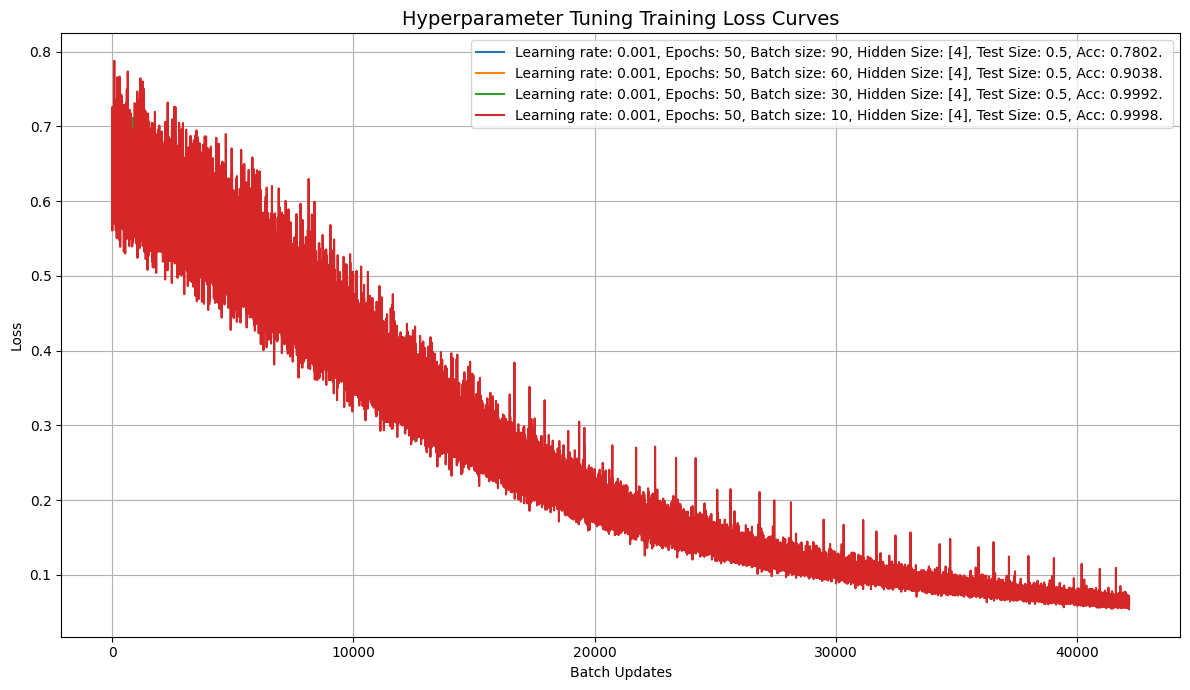


======== HYPERPARAMETER TUNING RESULT ========

Experiment: 1
Parameter
: {'lr': 0.001, 'epoch': 50, 'bs': 90, 'hidden': [4], 'test_size': 0.5}
Losses
: [0.651, 0.6528, 0.6567, 0.6694, 0.6551, 0.6441, 0.6571, 0.6382, 0.6534, 0.6595, 0.6606, 0.6686, 0.6389, 0.6484, 0.6559, 0.6393, 0.6402, 0.6778, 0.6331, 0.6506, 0.6678, 0.6202, 0.6651, 0.6609, 0.6308, 0.6427, 0.651, 0.6485, 0.6427, 0.6567, 0.6468, 0.654, 0.6136, 0.6304, 0.6413, 0.6239, 0.6625, 0.6348, 0.6339, 0.6337, 0.6372, 0.6406, 0.6518, 0.6855, 0.6494, 0.6375, 0.6591, 0.6536, 0.6227, 0.6349, 0.6562, 0.6365, 0.6389, 0.6451, 0.6333, 0.6144, 0.6485, 0.6338, 0.6357, 0.6215, 0.6451, 0.6425, 0.6231, 0.6386, 0.6422, 0.6246, 0.654, 0.6424, 0.6538, 0.659, 0.6749, 0.6299, 0.6424, 0.6419, 0.6448, 0.6395, 0.6398, 0.6414, 0.6392, 0.6333, 0.6463, 0.6638, 0.6566, 0.6445, 0.6681, 0.646, 0.6292, 0.6372, 0.6352, 0.6285, 0.6468, 0.6455, 0.6247, 0.6412, 0.6382, 0.6387, 0.6469, 0.6474, 0.6295, 0.645, 0.64, 0.6423, 0.6247, 0.6574, 0.6349, 0.6542, 0.6438

In [ ]:
# Hyperparameter - Variations Format: [variation, variation, ...]
# Save parameters, loss, and accuracy in provided sheet.

# Note: When experimenting a parameter, let the other parameter value follows constant value.
# Example: Experiment learning rate. Set learning rate: [0.1, 0.01, 0.001]. Set others by its constant value.

# CONSTANT VALUES:
# Learning rate: [0.001]
# Epochs: [50]
# Batch size: [100]
# Hidden size: [[4]]
# Test size: [0.5]

LEARNING_RATE = [0.001]
EPOCHS = [50]
BATCH_SIZE = [100]
HIDDEN_SIZE = [[4]]
TEST_SIZE = [0.5]

processor = dataProcessorDependencies()
model = BackPropagationNeuralNetwork()
activation = sigmoid
activation_deriv = sigmoid_derivative
loss = binaryCrossEntropyLoss
modeler = Modeler(
    data_processor=processor,
    test_size=TEST_SIZE,
    model=model,
    activation=activation,
    activation_deriv=activation_deriv,
    loss=loss,
    hidden_size=HIDDEN_SIZE,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE)

# Run modeler
parameters, losses_history, accuracy_history = modeler.run()

# Display parameter and its loss
print(f'\n======== HYPERPARAMETER TUNING RESULT ========\n')
for i, (param, losses, accuracy) in enumerate(zip(parameters, losses_history, accuracy_history)):
    print(f'Experiment: {i+1}')
    print(f'Parameter\n: {param}')
    print(f'Losses\n: {losses}')
    print(f'Accuracy\n: {accuracy}\n')